In [3]:
from pathlib import Path
import os

ROOT = Path("/Users/prathiksharamesh/single-cell-lung-atlas-covid19")

print(ROOT) 

/Users/prathiksharamesh/single-cell-lung-atlas-covid19


In [4]:
import scanpy as sc 
adata = sc.read_h5ad(
    ROOT / "data" / "processed" / "GSM5226574_C51ctr_raw_counts_doublet_removed.h5ad"
)

In [ ]:
adata.var['mt'] = adata.var.index.str.startswith('MT-') 

In [6]:
import pandas as pd
ribo_url = "http://software.broadinstitute.org/gsea/msigdb/download_geneset.jsp?geneSetName=KEGG_RIBOSOME&fileType=txt"

In [7]:
ribo_genes = pd.read_table(ribo_url, skiprows=2, header = None)
ribo_genes

,0
0,FAU
1,MRPL13
2,RPL10
3,RPL10A
4,RPL10L
...,...
83,RPS9
84,RPSA
85,RSL24D1
86,RSL24D1P11


In [8]:
adata.var['ribo'] = adata.var_names.isin(ribo_genes[0].values)

In [9]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo'], percent_top=None, log1p=False, inplace=True)

In [10]:
adata.var.sort_values('n_cells_by_counts')

,mt,ribo,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts
AL445072.1,False,False,0,0.000000,100.000000,0.0
AC113348.3,False,False,0,0.000000,100.000000,0.0
AL034346.1,False,False,0,0.000000,100.000000,0.0
AL445985.2,False,False,0,0.000000,100.000000,0.0
AL031963.2,False,False,0,0.000000,100.000000,0.0
...,...,...,...,...,...,...
AKAP13,False,False,4104,2.859870,28.113505,16327.0
NEAT1,False,False,4190,5.040813,26.607112,28778.0
MBNL1,False,False,4203,2.721317,26.379401,15536.0
ZBTB20,False,False,4327,2.429322,24.207392,13869.0


In [11]:
sc.pp.filter_genes(adata, min_cells=3)

In [12]:
adata.var.sort_values('n_cells_by_counts')

,mt,ribo,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells
AP000722.1,False,False,3,0.000525,99.947451,3.0,3
LINC01449,False,False,3,0.000525,99.947451,3.0,3
AC091074.2,False,False,3,0.000525,99.947451,3.0,3
AC073941.1,False,False,3,0.000525,99.947451,3.0,3
POU6F2-AS2,False,False,3,0.000525,99.947451,3.0,3
...,...,...,...,...,...,...,...
AKAP13,False,False,4104,2.859870,28.113505,16327.0,4104
NEAT1,False,False,4190,5.040813,26.607112,28778.0,4190
MBNL1,False,False,4203,2.721317,26.379401,15536.0,4203
ZBTB20,False,False,4327,2.429322,24.207392,13869.0,4327


In [13]:
adata.obs.sort_values('n_genes_by_counts')

,doublet,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo
TAGGGTTTCTGGCTGG-1_1,False,276,419.0,1.0,0.238663,1.0,0.238663
CGTGCTTCAAAGGGCT-1_1,False,277,432.0,41.0,9.490741,0.0,0.000000
TGACAGTTCTAAACGC-1_1,False,278,414.0,0.0,0.000000,0.0,0.000000
CTCTGGTCACGACGAA-1_1,False,285,407.0,0.0,0.000000,0.0,0.000000
GTAAGTCGTATCGCGC-1_1,False,289,430.0,0.0,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...
TGGGAAGTCAGTGATC-1_1,False,4719,11238.0,92.0,0.818651,11.0,0.097882
TAACTTCCAACCACGC-1_1,False,5158,15645.0,221.0,1.412592,211.0,1.348674
CACTGAAGTCGAAGCA-1_1,False,5487,12725.0,355.0,2.789784,82.0,0.644401
AGGCCACAGAGTCACG-1_1,False,5544,13217.0,417.0,3.155028,82.0,0.620413


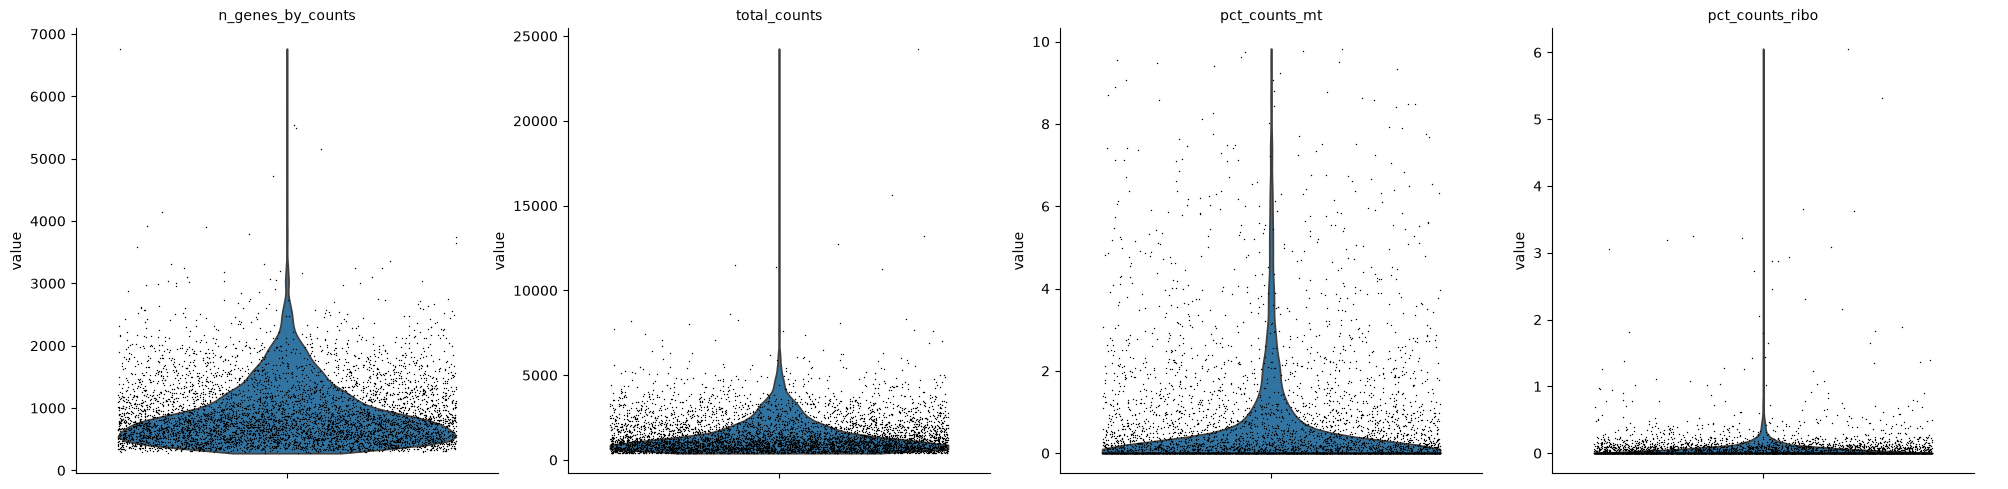

In [14]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo'], 
             jitter=0.4, multi_panel=True)

In [15]:
import numpy as np
upper_lim = np.quantile(adata.obs.n_genes_by_counts.values, .98)
#upper_lim = 3000

In [16]:
adata = adata[adata.obs.n_genes_by_counts < upper_lim]

In [17]:
adata = adata[adata.obs.pct_counts_mt < 20]

In [18]:
adata = adata[adata.obs.pct_counts_ribo < 2]

In [19]:
adata.X.sum(axis = 1)

array([5433., 5502., 5250., ...,  410.,  405.,  410.],
      shape=(5577,), dtype=float32)

In [20]:
sc.pp.normalize_total(adata, target_sum=1e4) #normalize every cell to 10,000 UMI

/opt/miniconda3/envs/lungatlas/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [21]:
adata.X.sum(axis = 1)

array([10000., 10000., 10000., ..., 10000., 10000., 10000.],
      shape=(5577,), dtype=float32)

In [22]:
sc.pp.log1p(adata)

In [23]:
adata.X.sum(axis = 1)

array([3285.3794 , 3163.8865 , 2858.1602 , ..., 1191.2708 , 1022.75116,
       1162.8784 ], shape=(5577,), dtype=float32)

In [25]:
adata.write_h5ad(ROOT / "data" / "processed" / "GSM5226574_C51ctr_normalized.h5ad")